# Champions Predictor - Parte 3: Visualizaciones Finales

## Objetivo
Crear visualizaciones profesionales para:
- Thread en X
- GitHub README
- Portafolio

## Visualizaciones
1. Probabilidades de campeón (barras)
2. Funnel por ronda
3. Comparación top equipos
4. Probabilidades octavos

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

## 1. Cargar Resultados

In [2]:
# Cargar probabilidades
df_prob = pd.read_csv('../data/processed/probabilidades_campeon.csv')

print("✅ Datos cargados")
print(f"\nTotal equipos: {len(df_prob)}")
print("\nTop 5 favoritos:")
print(df_prob.head()[['Ranking', 'Equipo', 'Prob_Campeon']])

✅ Datos cargados

Total equipos: 16

Top 5 favoritos:
   Ranking           Equipo  Prob_Campeon
0        1    Bayern Munich         34.18
1        2          Arsenal         18.75
2        3        Barcelona         15.32
3        4      Real Madrid          6.33
4        5  Sporting Lisboa          5.96


## 2. VIZ 1 - Probabilidades de Campeón (Principal)

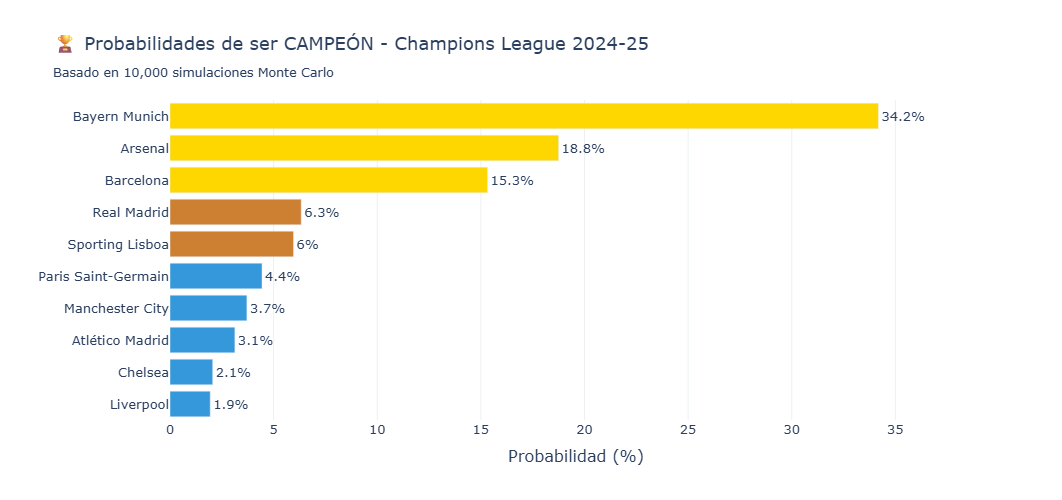

✅ Gráfico guardado


In [3]:
# Top 10 para no saturar
top_10 = df_prob.head(10)

fig1 = go.Figure()

# Colores por probabilidad
colors = []
for prob in top_10['Prob_Campeon']:
    if prob >= 15:
        colors.append('#FFD700')  # Oro
    elif prob >= 10:
        colors.append('#C0C0C0')  # Plata
    elif prob >= 5:
        colors.append('#CD7F32')  # Bronce
    else:
        colors.append('#3498db')  # Azul

fig1.add_trace(go.Bar(
    y=top_10['Equipo'][::-1],
    x=top_10['Prob_Campeon'][::-1],
    orientation='h',
    marker_color=colors[::-1],
    text=top_10['Prob_Campeon'][::-1].round(1),
    texttemplate='%{text}%',
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Probabilidad: %{x:.1f}%<extra></extra>'
))

fig1.update_layout(
    title='🏆 Probabilidades de ser CAMPEÓN - Champions League 2024-25<br><sub>Basado en 10,000 simulaciones Monte Carlo</sub>',
    xaxis_title='Probabilidad (%)',
    yaxis_title='',
    plot_bgcolor='white',
    height=500,
    font=dict(size=13),
    showlegend=False
)

fig1.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1', range=[0, top_10['Prob_Campeon'].max() + 5])
fig1.show()

# Guardar
fig1.write_html('../visualizations/probabilidades_campeon.html')
#fig1.write_image('../visualizations/probabilidades_campeon.png', width=1200, height=700)
print("✅ Gráfico guardado")

## 3. VIZ 2 - Funnel por Ronda (Top 5)

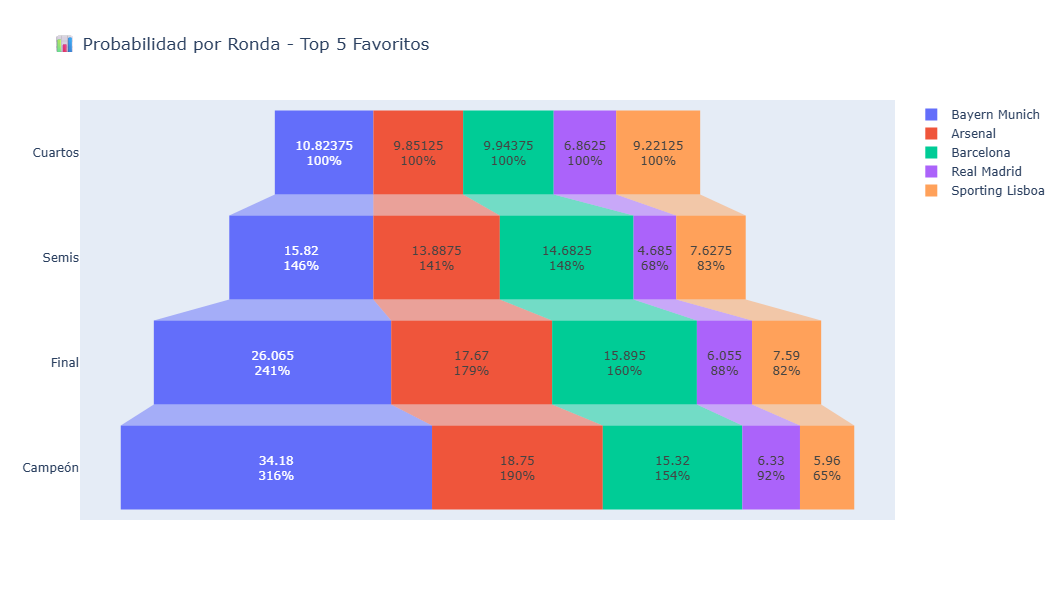

✅ Funnel guardado


In [4]:
# Top 5 equipos
top_5 = df_prob.head(5)

fig2 = go.Figure()

# Para cada equipo, crear un funnel
for idx, row in top_5.iterrows():
    fig2.add_trace(go.Funnel(
        name=row['Equipo'],
        y=['Cuartos', 'Semis', 'Final', 'Campeón'],
        x=[row['Prob_Cuartos'], row['Prob_Semi'], row['Prob_Final'], row['Prob_Campeon']],
        textinfo="value+percent initial"
    ))

fig2.update_layout(
    title='📊 Probabilidad por Ronda - Top 5 Favoritos',
    height=600,
    font=dict(size=12)
)

fig2.show()

# Guardar
fig2.write_html('../visualizations/funnel_por_ronda.html')
print("✅ Funnel guardado")

## 4. VIZ 3 - Comparación Rating vs Probabilidad

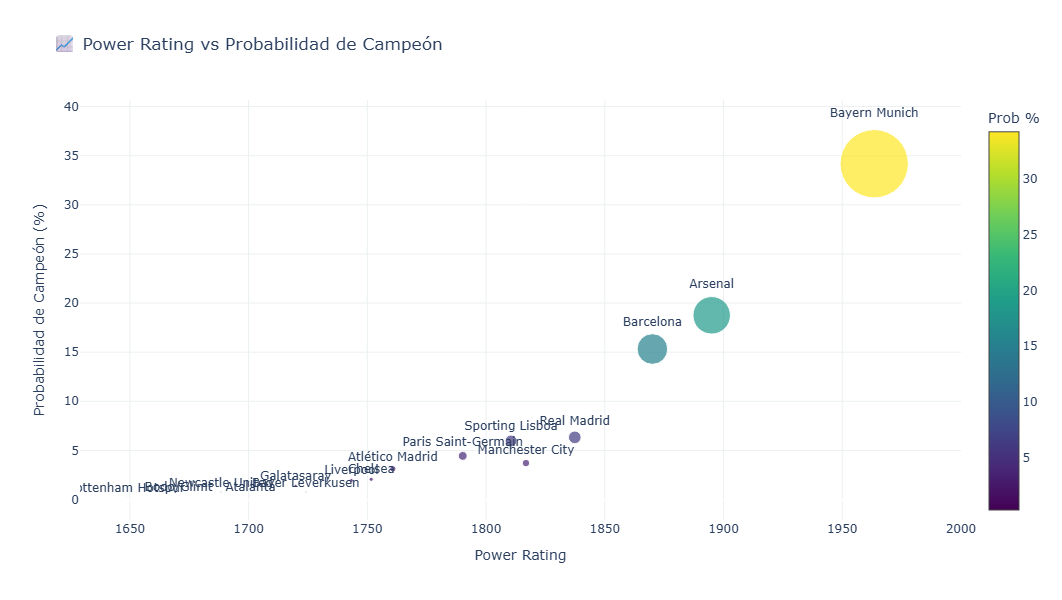

✅ Scatter guardado


In [5]:
fig3 = go.Figure()

# Scatter plot
fig3.add_trace(go.Scatter(
    x=df_prob['Rating'],
    y=df_prob['Prob_Campeon'],
    mode='markers+text',
    text=df_prob['Equipo'],
    textposition='top center',
    marker=dict(
        size=df_prob['Prob_Campeon'] * 2,
        color=df_prob['Prob_Campeon'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='Prob %')
    ),
    hovertemplate='<b>%{text}</b><br>Rating: %{x:.0f}<br>Prob: %{y:.1f}%<extra></extra>'
))

fig3.update_layout(
    title='📈 Power Rating vs Probabilidad de Campeón',
    xaxis_title='Power Rating',
    yaxis_title='Probabilidad de Campeón (%)',
    plot_bgcolor='white',
    height=600,
    font=dict(size=12)
)

fig3.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig3.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig3.show()

# Guardar
fig3.write_html('../visualizations/rating_vs_probabilidad.html')
print("✅ Scatter guardado")

## 5. VIZ 4 - Probabilidades por Octavos (para thread)

In [6]:
# Enfrentamientos de octavos
octavos = [
    ('Galatasaray', 'Liverpool'),
    ('Newcastle United', 'Barcelona'),
    ('Atlético Madrid', 'Tottenham Hotspur'),
    ('Atalanta', 'Bayern Munich'),
    ('Bayer Leverkusen', 'Arsenal'),
    ('Paris Saint-Germain', 'Chelsea'),
    ('Bodø/Glimt', 'Sporting Lisboa'),
    ('Real Madrid', 'Manchester City')
]

# Calcular prob de pasar octavos para cada equipo
# (simplificado: basado en prob de llegar a cuartos)
prob_octavos = []
for local, visitante in octavos:
    prob_local = df_prob[df_prob['Equipo'] == local]['Prob_Cuartos'].values[0]
    prob_visitante = df_prob[df_prob['Equipo'] == visitante]['Prob_Cuartos'].values[0]
    
    prob_octavos.append({
        'Enfrentamiento': f"{local} vs {visitante}",
        'Equipo_1': local,
        'Prob_1': prob_local,
        'Equipo_2': visitante,
        'Prob_2': prob_visitante
    })

df_octavos = pd.DataFrame(prob_octavos)

print("\n⚔️ PROBABILIDADES DE PASAR OCTAVOS:\n")
for idx, row in df_octavos.iterrows():
    print(f"{row['Enfrentamiento']}")
    print(f"  {row['Equipo_1']}: {row['Prob_1']:.1f}%")
    print(f"  {row['Equipo_2']}: {row['Prob_2']:.1f}%")
    print()


⚔️ PROBABILIDADES DE PASAR OCTAVOS:

Galatasaray vs Liverpool
  Galatasaray: 5.6%
  Liverpool: 6.9%

Newcastle United vs Barcelona
  Newcastle United: 2.6%
  Barcelona: 9.9%

Atlético Madrid vs Tottenham Hotspur
  Atlético Madrid: 8.7%
  Tottenham Hotspur: 3.8%

Atalanta vs Bayern Munich
  Atalanta: 1.7%
  Bayern Munich: 10.8%

Bayer Leverkusen vs Arsenal
  Bayer Leverkusen: 2.6%
  Arsenal: 9.9%

Paris Saint-Germain vs Chelsea
  Paris Saint-Germain: 7.2%
  Chelsea: 5.3%

Bodø/Glimt vs Sporting Lisboa
  Bodø/Glimt: 3.3%
  Sporting Lisboa: 9.2%

Real Madrid vs Manchester City
  Real Madrid: 6.9%
  Manchester City: 5.6%



## 6. Estadísticas para Thread

In [7]:
print("\n📊 STATS PARA EL THREAD:\n")

# Top 3
top_3 = df_prob.head(3)
print("Top 3 Favoritos:")
for idx, row in top_3.iterrows():
    print(f"{row['Ranking']}. {row['Equipo']}: {row['Prob_Campeon']:.1f}%")

# Concentración de probabilidad
prob_top_3 = top_3['Prob_Campeon'].sum()
prob_top_5 = df_prob.head(5)['Prob_Campeon'].sum()

print(f"\nLos 3 favoritos concentran: {prob_top_3:.1f}% de probabilidad")
print(f"Los 5 favoritos concentran: {prob_top_5:.1f}% de probabilidad")

# Underdog con más chances
underdogs = df_prob[df_prob['Rating'] < 1750].nlargest(1, 'Prob_Campeon')
if len(underdogs) > 0:
    print(f"\nUnderdog con más chances: {underdogs.iloc[0]['Equipo']} ({underdogs.iloc[0]['Prob_Campeon']:.1f}%)")

# Partido más parejo
mas_parejo = df_octavos.copy()
mas_parejo['diferencia'] = abs(mas_parejo['Prob_1'] - mas_parejo['Prob_2'])
mas_parejo = mas_parejo.nsmallest(1, 'diferencia')

print(f"\nPartido más parejo de octavos:")
print(f"{mas_parejo.iloc[0]['Enfrentamiento']}")
print(f"  {mas_parejo.iloc[0]['Prob_1']:.1f}% vs {mas_parejo.iloc[0]['Prob_2']:.1f}%")


📊 STATS PARA EL THREAD:

Top 3 Favoritos:
1. Bayern Munich: 34.2%
2. Arsenal: 18.8%
3. Barcelona: 15.3%

Los 3 favoritos concentran: 68.2% de probabilidad
Los 5 favoritos concentran: 80.5% de probabilidad

Underdog con más chances: Liverpool (1.9%)

Partido más parejo de octavos:
Real Madrid vs Manchester City
  6.9% vs 5.6%


## ✅ Visualizaciones Completadas

**Archivos generados:**
- `visualizations/probabilidades_campeon.html`
- `visualizations/probabilidades_campeon.png`
- `visualizations/funnel_por_ronda.html`
- `visualizations/rating_vs_probabilidad.html`

**Próximo paso:** README + Subir a GitHub